**Table of contents**<a id='toc0_'></a>    
- [Research Question: What predicts whether two countries have a trade agreement?](#toc1_)    
  - [Imports](#toc1_1_)    
  - [Upload Dataset](#toc1_2_)    
  - [Dataset Inspection](#toc1_3_)    
  - [Dataset Cleaning](#toc1_4_)    
  - [Logistic Regression Validation](#toc1_5_)    
  - [Random Forest Validation](#toc1_6_)    
  - [K Nearest Neighbors (KNN) Validation](#toc1_7_)    
  - [Final Train/Test for All Models](#toc1_8_)    
  - [Confusion Matrix for the Final KNN](#toc1_9_)    
  - [Feature Importance Chart for Final Random Forest](#toc1_10_)    
  - [Multi-Metric Comparison of Validation Models](#toc1_11_)    
  - [Multi-Metric Comparison of Final Test Models](#toc1_12_)    
  - [Limitations](#toc1_13_)    
  - [Ethics](#toc1_14_)    
  - [Reflection](#toc1_15_)    
  - [References](#toc1_16_)    
  - [AI Transparency](#toc1_17_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Research Question: What predicts whether two countries have a trade agreement?](#toc0_)

- Trade agreements affect everyday life through jobs, wages, prices, and access to goods. 
- Trade agreements matter for global development because they can shape whether countries are included in or excluded from the global economy. 
- Trade agreements can also influence diplomacy and international stability. 
- We chose this research question because it connects economics, politics, geography, and history in a way that has real social consequences. 
- This question investigates country-pair variables such as distance, GDP, population, political systems, shared institutions, and historical ties. 
- This research question is important because it helps explain why some country pairs formalize trade relationships while others do not.

## <a id='toc1_1_'></a>[Imports](#toc0_)

- pandas is used to load the dataset, create dataframes, and organize model results into tables. 
- numpy is imported to work with arrays and create row positions for the time-based validation folds. 
- matplotlib.pyplot is imported to create the feature importance chart, model comparison charts, and confusion matrix. 
- enable_iterative_imputer is imported so the iterative imputer can be used in sklearn. 
- IterativeImputer is imported to handle missing data and imputing missing numeric values. 
- RandomForestRegressor is imported to estimate missing numeric values inside the iterative imputer. 
- ColumnTransformer is imported so numeric and categorical variables can be processed differently. 
- Pipeline is imported to combine preprocessing steps and the model into one so there is reduced leakage. 
- StandardScaler is imported to scale numeric variables for logistic regression and K nearest neighbors. 
- OneHotEncoder is imported to convert categorical variables into dummy variables. 
- LogisticRegression is imported to run logistic regression. 
- cross_validate is imported to run cross validation and calculate model performance across multiple validation folds. 
- RandomForestClassifier is imported for random forest model. 
- KNeighborsClassifier is imported for KNN model. 
- precision_score, recall_score, f1_score, and roc_auc_score are imported to evaluate the models. 
- confusion_matrix is imported to create a confusion matrix. 
- ConfusionMatrixDisplay is imported to graph the confusion matrix in a more readable way.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## <a id='toc1_2_'></a>[Upload Dataset](#toc0_)

- The Dynamic Gravity Dataset was chosen because it matches our research question by providing country-pair observations over time. It includes geographic, economic, political, institutional, and historical variables related to trade agreements.
- The dataset is from data.gov and made by the US International Trade Commission.
- The dataset is a .csv document.
- The Dynamic Gravity Dataset version used in this project covers 2005 to 2016. This shorter time period was chosen instead of the full historical dataset to reduce model processing time while still keeping a large and useful sample.
- The dataset contains 746,048 observations and 70 variables.
- Dataset is made up of floats, ints, objects, and null values.
- Each observation represents a pair of countries in a given year. The unit of analysis is a country-pair-year.
- The target variable is agree_pta. It is a binary indicator of whether two countries have a trade agreement.
- Key variables include distance, contiguity, common language, GDP, population, polity, sanctions, colonial history, and joint membership in institutions.
- Sanity checks to ensure the dataset was uploaded correctly.

In [2]:
# Imports dataset as Trade_DB
Trade_DB = pd.read_csv("../Datasets/Trade_Dataset.csv")

# Sanity check if dataset was imported
print(Trade_DB.head())
print(Trade_DB.tail())
Trade_DB.info()

   year country_d iso3_d dynamic_code_d  landlocked_d  island_d   region_d  \
0  2005     Aruba    ABW            ABW             0         1  caribbean   
1  2006     Aruba    ABW            ABW             0         1  caribbean   
2  2007     Aruba    ABW            ABW             0         1  caribbean   
3  2008     Aruba    ABW            ABW             0         1  caribbean   
4  2009     Aruba    ABW            ABW             0         1  caribbean   

   gdp_pwt_const_d     pop_d  gdp_pwt_cur_d  ...  hostility_level_o  \
0        3906.5203  0.100031      4093.2434  ...                  0   
1        4118.1396  0.100830      4217.0669  ...                  0   
2        4196.4634  0.101218      4248.4707  ...                  0   
3        4433.6772  0.101342      4441.8828  ...                  0   
4        4183.0449  0.101416      4304.9224  ...                  0   

   hostility_level_d     distance  common_language  \
0                  0    120.05867                1

## <a id='toc1_3_'></a>[Dataset Inspection](#toc0_)

- The target variable (agree_pta) is binary and imbalanced (86.66% of observations coded 0 and 13.34% coded 1)
- Because of the class imbalance, accuracy alone would be misleading. Precision, recall, F1 score, and ROC-AUC will be considered as well. 
- The dataset contains no exact duplicate rows and no duplicate country-pair-year combinations. 
- The dataset includes 2,992 self-pairs and mirrored country-pair observations in both directions for most pair-years. These features can make prediction easier and create leakage concerns.
- Many economic and political variables contain missing values. These have the most missing variables: capital stock, GDP, population, polity, and sanctions variables.
- The missing values are all numeric variables.
-  There are no missing categorical variables.

In [3]:
# Shows dataset size
print("Shape of Trade_DB:")
print(Trade_DB.shape)
print()

# Shows column names
print("Column names:")
print(Trade_DB.columns.tolist())
print()

# Shows the data type of each column
print("Data types:")
print(Trade_DB.dtypes.sort_index())
print()

# Checks year range in the dataset
print("Year range:")
print(Trade_DB["year"].min(), Trade_DB["year"].max())
print()

# Checks target variable and shows count of each class
print("Target variable counts:")
print(Trade_DB["agree_pta"].value_counts(dropna=False).sort_index())
print()

# Shows the percentage of each class
print("Target variable percentages:")
print(Trade_DB["agree_pta"].value_counts(normalize=True, dropna=False).sort_index() * 100)
print()

# Counts missing values and sorts from most to least
Trade_DB_missing_counts = Trade_DB.isna().sum().sort_values(ascending=False)

# Shows percentage of missing values
Trade_DB_missing_percent = (Trade_DB.isna().mean() * 100).sort_values(ascending=False)

# Creates table of missing counts and percentages
Trade_DB_missing_table = pd.DataFrame({
    "missing_count": Trade_DB_missing_counts,
    "missing_percent": Trade_DB_missing_percent
})

# Prints columns with missing values
print("Missing values by column:")
print(Trade_DB_missing_table[Trade_DB_missing_table["missing_count"] > 0].head(30))
print()

# Counts duplicate rows
print("Exact duplicate rows:")
print(Trade_DB.duplicated().sum())
print()

# Checks duplicate combinations of year, origin country, and destination country
print("Duplicate year-iso3_o-iso3_d combinations:")
print(Trade_DB.duplicated(subset=["year", "iso3_o", "iso3_d"]).sum())
print()

# Counts self-pairs where the origin and destination are the same country
print("Self-pairs where iso3_o == iso3_d:")
print((Trade_DB["iso3_o"] == Trade_DB["iso3_d"]).sum())
print()

# Creates an undirected country-pair key
# Treats A to B and B to A as the same pair by sorting the country codes
# Attaches year to each so pair-year can be counted
Trade_DB_pair_key = Trade_DB.apply(
    lambda row: tuple(sorted([row["iso3_o"], row["iso3_d"]])) + (row["year"],),
    axis=1
)

# Counts how many times each undirected pair-year appears
Trade_DB_pair_counts = Trade_DB_pair_key.value_counts().sort_index()

# Prints how often pair-years appear
print("Undirected pair-year counts:")
print(Trade_DB_pair_counts.value_counts().sort_index())
print()

# Counts rows where the origin or destination country code is missing
print("Rows with missing origin or destination country codes:")
print(Trade_DB[["iso3_o", "iso3_d"]].isna().any(axis=1).sum())
print()

# Creates a list of all numeric columns
Trade_DB_numeric_cols = Trade_DB.select_dtypes(include=[np.number]).columns.tolist()

# Creates a dictionary for columns that contain negative values
Trade_DB_negative_summary = {}

# Counts how many negative values in each numeric column
for col in Trade_DB_numeric_cols:
    Trade_DB_negative_count = (Trade_DB[col] < 0).sum()
    if Trade_DB_negative_count > 0:
        Trade_DB_negative_summary[col] = Trade_DB_negative_count

# Prints columns with negative values
print("Columns with negative values:")
print(pd.Series(Trade_DB_negative_summary).sort_values(ascending=False))
print()

# Lists columns that should be binary
Trade_DB_binary_candidates = [
    "agree_pta",
    "agree_pta_goods",
    "agree_pta_services",
    "agree_cu",
    "agree_eia",
    "agree_fta",
    "agree_psa",
    "member_eu_joint",
    "member_wto_joint",
    "member_gatt_joint",
    "common_language",
    "contiguity",
    "colony_of_destination_after45",
    "colony_of_destination_current",
    "colony_of_destination_ever",
    "colony_of_origin_after45",
    "colony_of_origin_current",
    "colony_of_origin_ever"
]

# Prints the unique values in each binary column
print("Binary-column value checks:")
for col in Trade_DB_binary_candidates:
    if col in Trade_DB.columns:
        print(col, sorted(Trade_DB[col].dropna().unique().tolist()))
print()

# Leakage columns for agree_pta that cannot be predictors 
Trade_DB_leakage_cols = [
    "agree_pta_goods",
    "agree_pta_services",
    "agree_cu",
    "agree_eia",
    "agree_fta",
    "agree_psa"
]

# Prints leakage columns in the dataset
print("Leakage columns present:")
print([col for col in Trade_DB_leakage_cols if col in Trade_DB.columns])
print()

Shape of Trade_DB:
(746048, 70)

Column names:
['year', 'country_d', 'iso3_d', 'dynamic_code_d', 'landlocked_d', 'island_d', 'region_d', 'gdp_pwt_const_d', 'pop_d', 'gdp_pwt_cur_d', 'capital_cur_d', 'capital_const_d', 'gdp_wdi_cur_d', 'gdp_wdi_const_d', 'gdp_wdi_cap_cur_d', 'gdp_wdi_cap_const_d', 'lat_d', 'lng_d', 'polity_d', 'polity_abs_d', 'country_o', 'iso3_o', 'dynamic_code_o', 'landlocked_o', 'island_o', 'region_o', 'gdp_pwt_const_o', 'pop_o', 'gdp_pwt_cur_o', 'capital_cur_o', 'capital_const_o', 'gdp_wdi_cur_o', 'gdp_wdi_const_o', 'gdp_wdi_cap_cur_o', 'gdp_wdi_cap_const_o', 'lat_o', 'lng_o', 'polity_o', 'polity_abs_o', 'contiguity', 'agree_pta_goods', 'agree_pta_services', 'agree_cu', 'agree_eia', 'agree_fta', 'agree_psa', 'agree_pta', 'sanction_threat', 'sanction_threat_trade', 'sanction_imposition', 'sanction_imposition_trade', 'member_eu_o', 'member_wto_o', 'member_gatt_o', 'member_eu_d', 'member_wto_d', 'member_gatt_d', 'member_eu_joint', 'member_wto_joint', 'member_gatt_joint

## <a id='toc1_4_'></a>[Dataset Cleaning](#toc0_)

- Dropped leakage variables: agree_pta_goods, agree_pta_services, agree_cu, agree_eia, agree_fta, and agree_psa. 
- Dropped colony_of_destination_current and colony_of_origin_current because they only contain 0. 
- Dropped self-pairs because trade agreements between a country and itself are not relevant to the research question.
- Dropped the 4 capital stock variables: capital_cur_o, capital_const_o, capital_cur_d, and capital_const_d. They had about 40.29% missing values. 
- Dropped the 4 Penn World Table GDP variables: gdp_pwt_const_o, gdp_pwt_cur_o, gdp_pwt_const_d, and gdp_pwt_cur_d. They had about 39.99% missing values. 
- Dropped polity_abs_o and polity_abs_d because polity_o and polity_d were kept.
- Kept gdp_wdi_const_o and gdp_wdi_const_d to have a GDP variable. They had the least amount of missing data compared to the other GDP variables. 
- Dropped the broader sanctions variables (sanction_threat, sanction_imposition), but kept the trade-specific sanctions variables (sanction_threat_trade, sanction_imposition_trade).
- Dropped latitude and longitude variables because there were better geographic variables like distance and contiguity.
- Dropped identifier variables because they identify specific countries rather than general country-pair patterns.
- Dropped the individual EU, WTO, and GATT membership variables in favor of joint membership variables (member_eu_joint, member_wto_joint, and member_gatt_joint). 
- Dropped the narrower colonial relationship variables (colony_of_destination_after45, colony_of_origin_after45) in favor of the broader colonial relationship variables (colony_of_destination_ever, colony_of_origin_ever). 
- Variables with missing data were handled within individual model pipelines instead of imputing here to prevent leakage.
- The dataset contains directional country-pair observations. These observations were kept because some gravity dataset variables are directional, but this may make the dataset partly redundant.

In [4]:
# Creates a dataframe that removes self-pairs (origin country and destination country are the same)
Trade_DB_no_self = Trade_DB[Trade_DB["iso3_o"] != Trade_DB["iso3_d"]].copy()

# Creates list of columns to remove from the dataset
# Removes leakage predictors
Trade_DB_drop_cols = [
    "agree_pta_goods",
    "agree_pta_services",
    "agree_cu",
    "agree_eia",
    "agree_fta",
    "agree_psa",
    
    # Removes these columns because they are binary and only contain 0
    "colony_of_destination_current",
    "colony_of_origin_current",
    
    # Removes capital stock variables with high missing values
    "capital_cur_o",
    "capital_const_o",
    "capital_cur_d",
    "capital_const_d",
    
    # Removes Penn World Table GDP variables with high missing values
    "gdp_pwt_const_o",
    "gdp_pwt_cur_o",
    "gdp_pwt_const_d",
    "gdp_pwt_cur_d",
    
    # Removes polity_abs variables because polity variables are kept
    "polity_abs_o",
    "polity_abs_d",
    
    # Removes redundant World Bank GDP variables
    "gdp_wdi_cap_const_o",
    "gdp_wdi_cap_const_d",
    "gdp_wdi_cap_cur_o",
    "gdp_wdi_cap_cur_d",
    "gdp_wdi_cur_o",
    "gdp_wdi_cur_d",
    
    # Removes broader sanction variables because trade-specific sanction variables are kept
    "sanction_threat",
    "sanction_imposition",
    
    # Removes lat and long variables because distance and contiguity are kept
    "lat_o",
    "lng_o",
    "lat_d",
    "lng_d",

    # Removes identifier variables
    "country_o",
    "country_d",
    "iso3_o",
    "iso3_d",
    "dynamic_code_o",
    "dynamic_code_d",

    # Removes individual EU, WTO, and GATT membership variables because joint membership variables are kept
    "member_eu_o",
    "member_wto_o",
    "member_gatt_o",
    "member_eu_d",
    "member_wto_d",
    "member_gatt_d",

    # Removes narrower colonial relationship variables because broader colonial variables are kept
    "colony_of_destination_after45",
    "colony_of_origin_after45"
]

# Creates a modeling dataframe without leakage columns, colony_of_destination_current, colony_of_origin_current, and self-pairs
Trade_DB_model = Trade_DB_no_self.drop(columns=Trade_DB_drop_cols)

# Sanity checks on the cleaned dataset
print("Shape of Trade_DB:")
print(Trade_DB.shape)
print()
print("Shape of Trade_DB_no_self:")
print(Trade_DB_no_self.shape)
print()
print("Shape of Trade_DB_model:")
print(Trade_DB_model.shape)
print()
print("Columns removed from Trade_DB_model:")
print(Trade_DB_drop_cols)
print()
print("Columns in Trade_DB_model:")
print(Trade_DB_model.columns.tolist())

Shape of Trade_DB:
(746048, 70)

Shape of Trade_DB_no_self:
(743056, 70)

Shape of Trade_DB_model:
(743056, 26)

Columns removed from Trade_DB_model:
['agree_pta_goods', 'agree_pta_services', 'agree_cu', 'agree_eia', 'agree_fta', 'agree_psa', 'colony_of_destination_current', 'colony_of_origin_current', 'capital_cur_o', 'capital_const_o', 'capital_cur_d', 'capital_const_d', 'gdp_pwt_const_o', 'gdp_pwt_cur_o', 'gdp_pwt_const_d', 'gdp_pwt_cur_d', 'polity_abs_o', 'polity_abs_d', 'gdp_wdi_cap_const_o', 'gdp_wdi_cap_const_d', 'gdp_wdi_cap_cur_o', 'gdp_wdi_cap_cur_d', 'gdp_wdi_cur_o', 'gdp_wdi_cur_d', 'sanction_threat', 'sanction_imposition', 'lat_o', 'lng_o', 'lat_d', 'lng_d', 'country_o', 'country_d', 'iso3_o', 'iso3_d', 'dynamic_code_o', 'dynamic_code_d', 'member_eu_o', 'member_wto_o', 'member_gatt_o', 'member_eu_d', 'member_wto_d', 'member_gatt_d', 'colony_of_destination_after45', 'colony_of_origin_after45']

Columns in Trade_DB_model:
['year', 'landlocked_d', 'island_d', 'region_d', 'pop

## <a id='toc1_5_'></a>[Logistic Regression Validation](#toc0_)

- Logistic regression was chosen as a baseline model. 
- Year is separated from the predictor dataset so earlier years can be used for training and later years can be used for validation. 
- Random forest is used inside the iterative imputer to estimate missing numeric values. 
- Numeric data is separated from categorical data because they are processed differently. 
- The numeric imputer uses 25 trees, a maximum depth of 10, and a minimum of 20 observations in each leaf. 
- The numeric imputer goes through 5 rounds of imputation and uses 10 nearby features when estimating a missing value. 
- There is no missing categorical data in the cleaned dataset, so categorical imputation is not needed. 
- Categorical variables are one hot encoded into dummy variables of 0 and 1. If the validation set contains a category that was not in the training set, it is ignored. 
- Balanced class weights are used so the model pays more attention to the minority class because of class imbalance.
- For each validation fold, the training set included all years from 2005 up to the year before the validation year.
- This makes the evaluation more realistic because the model is always trained on past data and validated on future data. 
- 2015–2016 were left out of model development for the final test.
- Cross validation is run for the logistic regression model to evaluate how well it performs on unseen data instead of only on the data used to train it. 
- Cross validation calculates precision, recall, F1 score, and ROC-AUC. 
- For each fold: the pipeline first preprocesses the training data, then fits the logistic regression model, and then evaluates it on the validation year. 
- Precision measures how often the model is correct when it predicts that a country pair has a trade agreement. The low precision score means the model made a lot of false positive predictions. 
- Recall measures how many country pairs with trade agreements are correctly identified out of all the country pairs that actually have trade agreements. The higher recall score means the model does a good job identifying true trade agreement cases (true positives). 
- F1 score combines precision and recall into one measure. The low precision and higher recall give the model a moderate F1 score. 
- ROC-AUC measures how well the model separates the two classes across different thresholds. 
- The logistic regression results show class imbalance lowers precision but increases recall. The model identifies many true trade agreement cases, but it also makes many false positive predictions.

In [5]:
# Creates target variable (trade agreement) for logistic regression
Trade_DB_y_logit = Trade_DB_model["agree_pta"].copy()

# Creates year variable for time-based cross validation
Trade_DB_year_logit = Trade_DB_model["year"].copy()

# Creates predictor dataset for logistic regression
# Removes agree_pta because it is the target variable
# Removes year because it is used for cross validation
Trade_DB_X_logit = Trade_DB_model.drop(columns=["agree_pta", "year"]).copy()

# Creates list of numeric predictor columns
Trade_DB_numeric_cols_logit = Trade_DB_X_logit.select_dtypes(include=["number"]).columns.tolist()

# Creates list of categorical predictor columns
Trade_DB_categorical_cols_logit = Trade_DB_X_logit.select_dtypes(exclude=["number"]).columns.tolist()

# Creates random forest iterative imputer for numeric columns
# n_estimators=25 means there are 25 trees
# max_depth=10 means the depth of each tree can be up to 10
# min_samples_leaf=20 means the end points of the trees must have at least 20 observations
# random_state=42 ensures reproducibility
# n_jobs=-1 tells the computer to use all available CPU cores
# initial_strategy="median" tells the imputer to fill missing values with the GDP median before the iterative imputation 
# max_iter=5 tells the imputer to make 5 rounds of imputation
# n_nearest_features=10 tells the imputer to use the 10 most useful nearby features when imputing a missing value
# skip_complete=True tells the imputer to skip complete cases
# random_state=42 ensures reproducibility
Trade_DB_numeric_imputer_logit = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=25,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    initial_strategy="median",
    max_iter=5,
    n_nearest_features=10,
    skip_complete=True,
    random_state=42
)

# Fills missing numeric values with the imputer then scales the numeric columns 
Trade_DB_numeric_pipe_logit = Pipeline([
    ("imputer", Trade_DB_numeric_imputer_logit),
    ("scaler", StandardScaler())
])

# One-hot encodes categorical columns
# If the testing set has a category that was not in the training set, it ignores the unknown category
Trade_DB_categorical_pipe_logit = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combines numeric and categorical pipelines into a single column
Trade_DB_preprocess_logit = ColumnTransformer([
    ("num", Trade_DB_numeric_pipe_logit, Trade_DB_numeric_cols_logit),
    ("cat", Trade_DB_categorical_pipe_logit, Trade_DB_categorical_cols_logit)
])

# Creates the logistic regression pipeline
# max_iter=1000 gives the model more chances to finish fitting.
# class_weight="balanced" tells the model to weigh the minority class more to help with class imbalance
# random_state=42 ensures reproducibility
Trade_DB_logit_pipeline = Pipeline([
    ("preprocess", Trade_DB_preprocess_logit),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Creates an empty list of time-based cross validation folds
Trade_DB_cv_splits_logit = []

# Creates validation folds from 2009-2014 one year at a time
# Uses all rows before the current validation year as the training set
# Uses only rows from the current validation year as the validation set
# Adds each training and validation index pair to the list of cross validation folds
for Trade_DB_val_year_logit in range(2009, 2015):
    Trade_DB_train_idx_logit = np.flatnonzero(Trade_DB_year_logit < Trade_DB_val_year_logit)
    Trade_DB_val_idx_logit = np.flatnonzero(Trade_DB_year_logit == Trade_DB_val_year_logit)
    Trade_DB_cv_splits_logit.append((Trade_DB_train_idx_logit, Trade_DB_val_idx_logit))

# Creates a dictionary of metrics for cross validation
Trade_DB_scoring_logit = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Runs cross validation for logistic regression
# estimator=Trade_DB_logit_pipeline estimator uses the pipeline that includes preprocessing and logistic regression
# X=Trade_DB_X_logit is the predictor variables
# y=Trade_DB_y_logit is the target variable
# cv=Trade_DB_cv_splits_logit is the custom time-based folds
# scoring=Trade_DB_scoring_logit is the cross validation metrics
# return_train_score=False makes it so the training scores are not returned
# n_jobs=1 runs the cross-validation jobs one at a time
# error_score="raise" raises an error if something goes wrong
Trade_DB_cv_results_logit = cross_validate(
    estimator=Trade_DB_logit_pipeline,
    X=Trade_DB_X_logit,
    y=Trade_DB_y_logit,
    cv=Trade_DB_cv_splits_logit,
    scoring=Trade_DB_scoring_logit,
    return_train_score=False,
    n_jobs=1,
    error_score="raise"
)

# Creates dataframe of fold-by-fold cross validation results
Trade_DB_cv_summary_logit = pd.DataFrame({
    "validation_year": [2009, 2010, 2011, 2012, 2013, 2014],
    "precision": Trade_DB_cv_results_logit["test_precision"],
    "recall": Trade_DB_cv_results_logit["test_recall"],
    "f1": Trade_DB_cv_results_logit["test_f1"],
    "roc_auc": Trade_DB_cv_results_logit["test_roc_auc"]
})

# Prints fold-by-fold results
print("Logistic regression cross validation results by year:")
print(Trade_DB_cv_summary_logit)
print()

# Prints average cross validation results
print("Average logistic regression cross validation results:")
print(Trade_DB_cv_summary_logit[["precision", "recall", "f1", "roc_auc"]].mean())

c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not 

Logistic regression cross validation results by year:
   validation_year  precision    recall        f1   roc_auc
0             2009   0.268417  0.670848  0.383421  0.775402
1             2010   0.271719  0.673391  0.387199  0.780215
2             2011   0.274337  0.675432  0.390191  0.784998
3             2012   0.278412  0.667988  0.393018  0.783615
4             2013   0.285127  0.650729  0.396515  0.776722
5             2014   0.301717  0.668745  0.415826  0.786448

Average logistic regression cross validation results:
precision    0.279955
recall       0.667855
f1           0.394362
roc_auc      0.781233
dtype: float64


## <a id='toc1_6_'></a>[Random Forest Validation](#toc0_)

- Random forest was chosen because it is a tree based model that can capture more complex nonlinear patterns. 
- Random forest can handle missing numeric values, so numeric imputation is not needed. 
- There is no missing categorical data, so categorical imputation is not needed. 
- Random forest does not need scaling, so the numeric variables do not need to be standardized. 
- Categorical variables are one hot encoded into dummy variables of 0 and 1. If the validation set contains a category that was not in the training set, it is ignored. 
- Random forest uses 300 trees and a minimum of 5 observations in each leaf. 
- Random forest uses balanced samples to help with the class imbalance in the dataset. 
- For each validation fold, the training set included all years from 2005 up to the year before the validation year.
- This makes the evaluation more realistic because the model is always trained on past data and validated on future data. 
- 2015–2016 were left out of model development for the final test.
- Cross validation is run for the random forest model to evaluate how well it performs on unseen data instead of only on the data used to train it. 
- Cross validation calculates precision, recall, F1 score, and ROC-AUC. 
- For each fold, the pipeline first preprocesses the training data, then fits the random forest model, and then evaluates it on the validation year. 
- Precision measures how often the model is correct when it predicts that a country pair has a trade agreement. The very high precision score means the model makes very few false positive predictions. 
- Recall measures how many country pairs with trade agreements are correctly identified out of all the country pairs that actually have trade agreements. The very high recall score means the model identifies most true trade agreement cases. 
- F1 score combines precision and recall into one measure. The high F1 score means the model has a very strong balance between correctly identifying trade agreements and avoiding false positive predictions. 
- ROC-AUC measures how well the model separates the two classes across different thresholds. The very high ROC-AUC score means the model separates country pairs with trade agreements from those without them extremely well. 
- The random forest results were much stronger than the logistic regression results on every evaluation metric. 
- Both precision and recall were very high. This means the model correctly identified most trade agreement cases while keeping false positive predictions low. 
- The results suggest that a tree based model is better at capturing the structure of the dataset than logistic regression. 
- A limitation is that the very strong random forest results may reflect repeated country pair patterns across years. This makes prediction easier.

In [6]:
# Creates target variable (trade agreement) for random forest
Trade_DB_y_rf = Trade_DB_model["agree_pta"].copy()

# Creates year variable for time-based cross validation
Trade_DB_year_rf = Trade_DB_model["year"].copy()

# Creates predictor dataset for random forest
# Removes agree_pta because it is the target variable
# Removes year because it is used for cross validation
Trade_DB_X_rf = Trade_DB_model.drop(columns=["agree_pta", "year"]).copy()

# Creates list of numeric predictor columns
Trade_DB_numeric_cols_rf = Trade_DB_X_rf.select_dtypes(include=["number"]).columns.tolist()

# Creates list of categorical predictor columns
Trade_DB_categorical_cols_rf = Trade_DB_X_rf.select_dtypes(exclude=["number"]).columns.tolist()

# Creates preprocessing step for random forest
# Passes numeric columns through without scaling or imputing
# One-hot encodes categorical columns
# If the testing set has a category that was not in the training set, it ignores the unknown category
Trade_DB_preprocess_rf = ColumnTransformer([
    ("num", "passthrough", Trade_DB_numeric_cols_rf),
    ("cat", OneHotEncoder(handle_unknown="ignore"), Trade_DB_categorical_cols_rf)
])

# Creates random forest pipeline
# n_estimators=300 means there are 300 trees
# min_samples_leaf=5 means each leaf must have at least 5 observations
# class_weight="balanced_subsample" tells the model to pay more attention to the minority class.
# random_state=42 ensures reproducibility
# n_jobs=-1 tells the computer to use all available CPU cores
Trade_DB_rf_pipeline = Pipeline([
    ("preprocess", Trade_DB_preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

# Creates an empty list of time-based cross validation folds
Trade_DB_cv_splits_rf = []

# Creates validation folds from 2009-2014 one year at a time
# Uses all rows before the current validation year as the training set
# Uses only rows from the current validation year as the validation set
# Adds each training and validation index pair to the list of cross validation folds
for Trade_DB_val_year_rf in range(2009, 2015):
    Trade_DB_train_idx_rf = np.flatnonzero(Trade_DB_year_rf < Trade_DB_val_year_rf)
    Trade_DB_val_idx_rf = np.flatnonzero(Trade_DB_year_rf == Trade_DB_val_year_rf)
    Trade_DB_cv_splits_rf.append((Trade_DB_train_idx_rf, Trade_DB_val_idx_rf))

# Creates a dictionary of metrics for cross validation
Trade_DB_scoring_rf = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Runs cross validation for random forest
# estimator=Trade_DB_rf_pipeline estimator uses the pipeline that includes preprocessing and random forest
# X=Trade_DB_X_rf is the predictor variables
# y=Trade_DB_y_rf is the target variable
# cv=Trade_DB_cv_splits_rf is the custom time-based folds
# scoring=Trade_DB_scoring_rf is the cross validation metrics
# return_train_score=False makes it so the training scores are not returned
# n_jobs=1 runs the cross-validation jobs one at a time
# error_score="raise" raises an error if something goes wrong
Trade_DB_cv_results_rf = cross_validate(
    estimator=Trade_DB_rf_pipeline,
    X=Trade_DB_X_rf,
    y=Trade_DB_y_rf,
    cv=Trade_DB_cv_splits_rf,
    scoring=Trade_DB_scoring_rf,
    return_train_score=False,
    n_jobs=1,
    error_score="raise"
)

# Creates dataframe of fold-by-fold cross validation results
Trade_DB_cv_summary_rf = pd.DataFrame({
    "validation_year": [2009, 2010, 2011, 2012, 2013, 2014],
    "precision": Trade_DB_cv_results_rf["test_precision"],
    "recall": Trade_DB_cv_results_rf["test_recall"],
    "f1": Trade_DB_cv_results_rf["test_f1"],
    "roc_auc": Trade_DB_cv_results_rf["test_roc_auc"]
})

# Prints fold-by-fold results
print("Random forest cross validation results by year:")
print(Trade_DB_cv_summary_rf)
print()

# Prints average cross validation results
print("Average random forest cross validation results:")
print(Trade_DB_cv_summary_rf[["precision", "recall", "f1", "roc_auc"]].mean())

Random forest cross validation results by year:
   validation_year  precision    recall        f1   roc_auc
0             2009   0.889658  0.938626  0.913487  0.989404
1             2010   0.903992  0.946326  0.924674  0.995025
2             2011   0.899026  0.964337  0.930537  0.997044
3             2012   0.922628  0.939730  0.931100  0.988025
4             2013   0.945226  0.920384  0.932640  0.984652
5             2014   0.949802  0.953783  0.951788  0.995897

Average random forest cross validation results:
precision    0.918389
recall       0.943864
f1           0.930704
roc_auc      0.991674
dtype: float64


## <a id='toc1_7_'></a>[K Nearest Neighbors (KNN) Validation](#toc0_)

- KNN was chosen because it tests whether trade agreements can be predicted by similarity between country-pair observations. 
- Year is separated from the predictor dataset so earlier years can be used for training and later years can be used for validation. 
- Random forest is used inside the iterative imputer to estimate missing numeric values. 
- Numeric data is separated from categorical data because they are processed differently. 
- The numeric imputer uses 25 trees, a maximum depth of 10, and a minimum of 20 observations in each leaf. 
- The numeric imputer goes through 5 rounds of imputation and uses 10 nearby features when estimating a missing value. 
- There is no missing categorical data in the cleaned dataset, so categorical imputation is not needed. 
- Categorical variables are one hot encoded into dummy variables of 0 and 1. If the validation set contains a category that was not in the training set, it is ignored. 
- For each validation fold, the training set included all years from 2005 up to the year before the validation year.
- This makes the evaluation more realistic because the model is always trained on past data and validated on future data. 
- 2015–2016 were left out of model development for the final test.
- KNN uses distance to compare observations, so scaling is needed to keep larger numeric variables from skewing the distance calculation. 
- KNN model uses 15 neighbors and gives more weight to closer neighbors. 
- Cross validation is run for KNN to evaluate how well it performs on unseen data instead of only on the data it was trained on. 
- Cross validation calculates precision, recall, F1 score, and ROC-AUC. 
- For each fold, the pipeline first preprocesses the training data, then fits the KNN model, and then evaluates it on the validation year. 
- Precision measures how often the model is correct when it predicts that a country pair has a trade agreement. The very high precision score means the model makes very few false positive predictions. 
- Recall measures how many country pairs with trade agreements are correctly identified out of all the country pairs that actually have trade agreements. The recall score is strong, but it is lower than the random forest recall score. 
- F1 score combines precision and recall into one measure. The high F1 score means the model has a strong balance between correctly identifying trade agreements and avoiding false positive predictions. 
- ROC-AUC measures how well the model separates the two classes across different thresholds. The high ROC-AUC score means the model separates country pairs with trade agreements from those without them very well. 
- The KNN results were much stronger than the logistic regression results on every evaluation metric. 
- KNN had the highest precision of the three models (average precision 0.973). 
- Compared to random forest, KNN was more precise but had lower recall, lower F1, and lower ROC-AUC. 
- KNN performed very well, but it took a lot longer to run when compared to the other models. 
- A limitation is that the very strong KNN results may reflect repeated country pair patterns across years. This makes prediction easier.

In [7]:
# Creates target variable for K nearest neighbors
Trade_DB_y_knn = Trade_DB_model["agree_pta"].copy()

# Creates year variable for time-based cross validation
Trade_DB_year_knn = Trade_DB_model["year"].copy()

# Creates predictor dataset for K nearest neighbors
Trade_DB_X_knn = Trade_DB_model.drop(columns=["agree_pta", "year"]).copy()

# Creates list of numeric predictor columns
Trade_DB_numeric_cols_knn = Trade_DB_X_knn.select_dtypes(include=["number"]).columns.tolist()

# Creates list of categorical predictor columns
Trade_DB_categorical_cols_knn = Trade_DB_X_knn.select_dtypes(exclude=["number"]).columns.tolist()

# Creates random forest iterative imputer for numeric columns
# n_estimators=25 means there are 25 trees
# max_depth=10 means the depth of each tree can be up to 10
# min_samples_leaf=20 means the end points of the trees must have at least 20 observations
# random_state=42 ensures reproducibility
# n_jobs=-1 tells the computer to use all available CPU cores
# initial_strategy="median" tells the imputer to fill missing values with the GDP median before the iterative imputation 
# max_iter=5 tells the imputer to make 5 rounds of imputation
# n_nearest_features=10 tells the imputer to use the 10 most useful nearby features when imputing a missing value
# skip_complete=True tells the imputer to skip complete cases
# random_state=42 ensures reproducibility
Trade_DB_numeric_imputer_knn = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=25,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    initial_strategy="median",
    max_iter=5,
    n_nearest_features=10,
    skip_complete=True,
    random_state=42
)

# Fills missing numeric values with the imputer then scales the numeric columns 
Trade_DB_numeric_pipe_knn = Pipeline([
    ("imputer", Trade_DB_numeric_imputer_knn),
    ("scaler", StandardScaler())
])

# One-hot encodes categorical columns
# If the testing set has a category that was not in the training set, it ignores the unknown category
Trade_DB_categorical_pipe_knn = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combines numeric and categorical pipelines into a single column
Trade_DB_preprocess_knn = ColumnTransformer([
    ("num", Trade_DB_numeric_pipe_knn, Trade_DB_numeric_cols_knn),
    ("cat", Trade_DB_categorical_pipe_knn, Trade_DB_categorical_cols_knn)
])

# Creates K nearest neighbors pipeline
# n_neighbors=15 means the model looks at the 15 nearest observations when making a prediction
# weights=distance means closer neighbors matter more than farther neighbors.
Trade_DB_knn_pipeline = Pipeline([
    ("preprocess", Trade_DB_preprocess_knn),
    ("model", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance"
    ))
])

# Creates an empty list of time-based cross validation folds
Trade_DB_cv_splits_knn = []

# Creates validation folds from 2009-2014 one year at a time
# For each validation year, the training set includes all rows from earlier years
# The validation set includes only rows from the current validation year
for Trade_DB_val_year_knn in range(2009, 2015):
    Trade_DB_train_idx_knn = np.flatnonzero(Trade_DB_year_knn < Trade_DB_val_year_knn)
    Trade_DB_val_idx_knn = np.flatnonzero(Trade_DB_year_knn == Trade_DB_val_year_knn)
    Trade_DB_cv_splits_knn.append((Trade_DB_train_idx_knn, Trade_DB_val_idx_knn))

# Creates scoring metrics for cross validation
Trade_DB_scoring_knn = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Runs cross validation for K nearest neighbors
# estimator=Trade_DB_knn_pipeline estimator uses the pipeline that includes preprocessing and K nearest neighbors
# X=Trade_DB_X_knn is the predictor variables
# y=Trade_DB_y_knn is the target variable
# cv=Trade_DB_cv_splits_knn is the custom time-based folds
# scoring=Trade_DB_scoring_knn is the cross validation metrics
# return_train_score=False makes it so the training scores are not returned
# n_jobs=1 runs the cross-validation jobs one at a time
# error_score="raise" raises an error if something goes wrong
Trade_DB_cv_results_knn = cross_validate(
    estimator=Trade_DB_knn_pipeline,
    X=Trade_DB_X_knn,
    y=Trade_DB_y_knn,
    cv=Trade_DB_cv_splits_knn,
    scoring=Trade_DB_scoring_knn,
    return_train_score=False,
    n_jobs=1,
    error_score="raise"
)

# Creates dataframe of fold-by-fold cross validation results
Trade_DB_cv_summary_knn = pd.DataFrame({
    "validation_year": [2009, 2010, 2011, 2012, 2013, 2014],
    "precision": Trade_DB_cv_results_knn["test_precision"],
    "recall": Trade_DB_cv_results_knn["test_recall"],
    "f1": Trade_DB_cv_results_knn["test_f1"],
    "roc_auc": Trade_DB_cv_results_knn["test_roc_auc"]
})

# Prints fold-by-fold results
print("K nearest neighbors cross validation results by year:")
print(Trade_DB_cv_summary_knn)
print()

# Prints average cross validation results
print("Average K nearest neighbors cross validation results:")
print(Trade_DB_cv_summary_knn[["precision", "recall", "f1", "roc_auc"]].mean())

c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\conno\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\conno\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\conno\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execut

K nearest neighbors cross validation results by year:
   validation_year  precision    recall        f1   roc_auc
0             2009   0.973356  0.827448  0.894491  0.984480
1             2010   0.967515  0.844020  0.901558  0.985372
2             2011   0.971219  0.907661  0.938365  0.986823
3             2012   0.961832  0.910702  0.935569  0.983455
4             2013   0.988280  0.884607  0.933574  0.971313
5             2014   0.975893  0.865864  0.917592  0.982687

Average K nearest neighbors cross validation results:
precision    0.973016
recall       0.873384
f1           0.920192
roc_auc      0.982355
dtype: float64


## <a id='toc1_8_'></a>[Final Train/Test for All Models](#toc0_)

- A final training set from 2005 to 2014 and a final test set from 2015 to 2016 were created. 
- The final test set was held out until the end so the models could be evaluated on unseen future data after cross validation was completed. 
- Logistic regression, random forest, and KNN were each trained on the full 2005 to 2014 training period. 
- Each finalized model was then evaluated on the 2015 to 2016 test period. 
- The final test results include precision, recall, F1 score, and ROC-AUC.
- The final test results for logistic regression: precision of 0.309, recall of 0.636, F1 of 0.416, and ROC-AUC of 0.779. 
- The logistic regression results show lower precision and higher recall. This means the model identified many true trade agreement cases but also made many false positive predictions. 
- The final test results for random forest: precision of 0.906, recall of 0.415, F1 of 0.569, and ROC-AUC of 0.906. 
- The random forest results show very high precision but much lower recall than expected from cross validation. 
- This means the model was usually correct when it predicted a trade agreement, but it missed many true trade agreement cases on the final test set. 
- The final test results for KNN: precision of 0.848, recall of 0.628, F1 of 0.722, and ROC-AUC of 0.885. 
- The KNN results show a stronger balance between precision and recall than the other two models on the final test set. 
- KNN had the highest F1 score. This means it had the best overall balance between precision and recall. 
- Random forest had the highest precision and ROC-AUC. This means it was the most accurate when predicting trade agreements and separated the two classes very well. 
- Logistic regression had the weakest overall performance on the final test set. 
- The final test results were weaker than the cross validation results for random forest and KNN. This suggests that the cross validation results may have been helped by repeated country pair patterns across years. 
- The final test results suggest that KNN was the strongest model if the goal is to balance precision and recall, while random forest was the strongest model if the goal is to maximize precision.

In [8]:
# Creates final training set from 2005-2014
Trade_DB_train_final = Trade_DB_model[Trade_DB_model["year"] <= 2014].copy()

# Creates final test set from 2015-2016
Trade_DB_test_final = Trade_DB_model[Trade_DB_model["year"] >= 2015].copy()

# Creates predictor and target variables for the final training set
# Removes agree_pta because it is the target variable
# Removes year because it is not being used as a predictor
Trade_DB_X_train_final = Trade_DB_train_final.drop(columns=["agree_pta", "year"]).copy()
Trade_DB_y_train_final = Trade_DB_train_final["agree_pta"].copy()

# Creates predictor and target variables for the final test set
# Removes agree_pta because it is the target variable
# Removes year because it is not being used as a predictor
Trade_DB_X_test_final = Trade_DB_test_final.drop(columns=["agree_pta", "year"]).copy()
Trade_DB_y_test_final = Trade_DB_test_final["agree_pta"].copy()

# Creates dictionary of finalized models
Trade_DB_final_models = {
    "Logistic Regression": Trade_DB_logit_pipeline,
    "Random Forest": Trade_DB_rf_pipeline,
    "K Nearest Neighbors": Trade_DB_knn_pipeline
}

# Creates empty list to store final test results
Trade_DB_final_results_list = []

# Fits each model on the full 2005-2014 training set and evaluates it on the 2015-2016 test set
for Trade_DB_model_name_final, Trade_DB_pipeline_final in Trade_DB_final_models.items():
    
    # Fits the pipeline on the final training set
    Trade_DB_pipeline_final.fit(Trade_DB_X_train_final, Trade_DB_y_train_final)
    
    # Creates class predictions on the final test set
    Trade_DB_y_pred_final = Trade_DB_pipeline_final.predict(Trade_DB_X_test_final)
    
    # Creates predicted probabilities for the positive class on the final test set
    Trade_DB_y_score_final = Trade_DB_pipeline_final.predict_proba(Trade_DB_X_test_final)[:, 1]
    
    # Stores final test metrics for the current model
    Trade_DB_final_results_list.append({
        "model": Trade_DB_model_name_final,
        "precision": precision_score(Trade_DB_y_test_final, Trade_DB_y_pred_final),
        "recall": recall_score(Trade_DB_y_test_final, Trade_DB_y_pred_final),
        "f1": f1_score(Trade_DB_y_test_final, Trade_DB_y_pred_final),
        "roc_auc": roc_auc_score(Trade_DB_y_test_final, Trade_DB_y_score_final)
    })

# Creates dataframe of final test results
Trade_DB_final_results = pd.DataFrame(Trade_DB_final_results_list)

# Prints final test results table
print("Final test results on 2015-2016:")
print(Trade_DB_final_results)

c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Final test results on 2015-2016:
                 model  precision    recall        f1   roc_auc
0  Logistic Regression   0.308537  0.636325  0.415574  0.779271
1        Random Forest   0.905940  0.414690  0.568947  0.905666
2  K Nearest Neighbors   0.848111  0.628472  0.721956  0.884983


## <a id='toc1_9_'></a>[Confusion Matrix for the Final KNN](#toc0_)

- The confusion matrix is based on the KNN final test results for 2015 to 2016. 
- The top left value (104,673) is the number of true negatives. These are country pairs that did not have a trade agreement and were correctly predicted as having no trade agreement. 
- The top right value (2,107) is the number of false positives. These are country pairs that did not have a trade agreement but were incorrectly predicted as having one. 
- The low number of false positives helps explain why KNN had high precision. 
- The bottom left value (6,955) is the number of false negatives. These are country pairs that did have a trade agreement but were incorrectly predicted as not having one. 
- The model missing some true trade agreement cases is why recall was lower than precision. 
- The bottom right value (11,765) is the number of true positives. These are country pairs that did have a trade agreement and were correctly predicted as having one.
- The model was usually correct when it predicted that a trade agreement existed. 
- The confusion matrix shows that KNN did a strong job balancing false positives and false negatives on the final test set.

c:\Users\conno\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


K Nearest Neighbors confusion matrix:
[[104673   2107]
 [  6955  11765]]


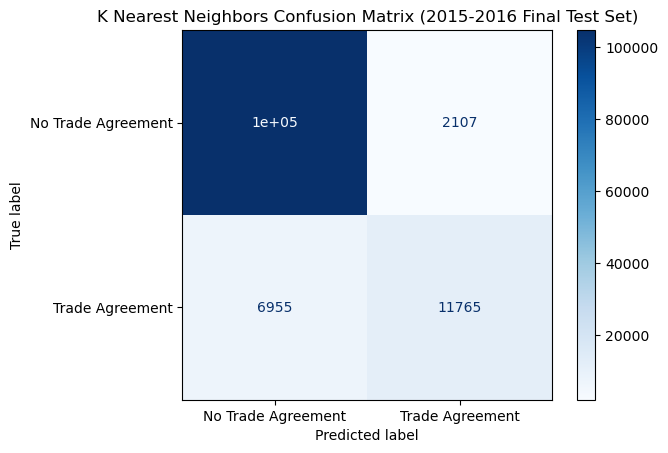

In [9]:
# Fits the KNN pipeline on the final training set
Trade_DB_knn_pipeline.fit(Trade_DB_X_train_final, Trade_DB_y_train_final)

# Creates final test predictions for K nearest neighbors
Trade_DB_y_pred_knn_final = Trade_DB_knn_pipeline.predict(Trade_DB_X_test_final)

# Creates confusion matrix from the final test predictions
Trade_DB_knn_conf_matrix = confusion_matrix(Trade_DB_y_test_final, Trade_DB_y_pred_knn_final)

# Prints the confusion matrix values
print("K Nearest Neighbors confusion matrix:")
print(Trade_DB_knn_conf_matrix)

# Creates confusion matrix
Trade_DB_knn_conf_display = ConfusionMatrixDisplay(
    confusion_matrix=Trade_DB_knn_conf_matrix,
    display_labels=["No Trade Agreement", "Trade Agreement"]
)

# Plots the confusion matrix
Trade_DB_knn_conf_display.plot(cmap="Blues")
plt.title("K Nearest Neighbors Confusion Matrix (2015-2016 Final Test Set)")
plt.show()

## <a id='toc1_10_'></a>[Feature Importance Chart for Final Random Forest](#toc0_)

- The feature importance graph shows which variables were most useful for predicting trade agreements in the final random forest model. 
- Distance is the most important variable by a large margin. This suggests that geographic proximity is the strongest predictor of whether two countries have a trade agreement according to the final random forest model. 
- GDP variables for both countries (gdp_wdi_const_d, gdp_wdi_const_o) are the next most important features. This suggests that larger economies are more likely to have trade agreements. 
- Population variables (pop_d, pop_o) are also important. This suggests that larger countries are more likely to engage in trade agreements. 
- Political variables (polity_o, polity_d) have moderate importance. This suggests that political systems play a role in trade agreements but are less important than geography and economic size. 
- Regional variables (like region_d_europe and region_o_europe) appear in the top 10. This suggests that certain regions are associated with a higher likelihood of trade agreements. Distance most likely plays a part in this variable’s importance.
- The variable member_gatt_joint is also in the top 10. This suggests that shared membership in international trade institutions is associated with trade agreements. 
- The most important predictors are geographic, economic, and institutional variables. Political variables are less influential. 
- These results suggest that distance and economic size are the strongest factors associated with trade agreements in this dataset. 
- The feature importance results show which variables are useful for prediction, but they do not prove that these variables cause trade agreements.
- Impurity-based feature importance can favor continuous variables or variables with many possible split points.

              feature  importance
18           distance    0.194539
3     gdp_wdi_const_d    0.095771
8     gdp_wdi_const_o    0.095492
2               pop_d    0.077963
7               pop_o    0.077316
9            polity_o    0.064417
4            polity_d    0.063787
28    region_d_europe    0.029448
15  member_gatt_joint    0.029181
42    region_o_europe    0.028788


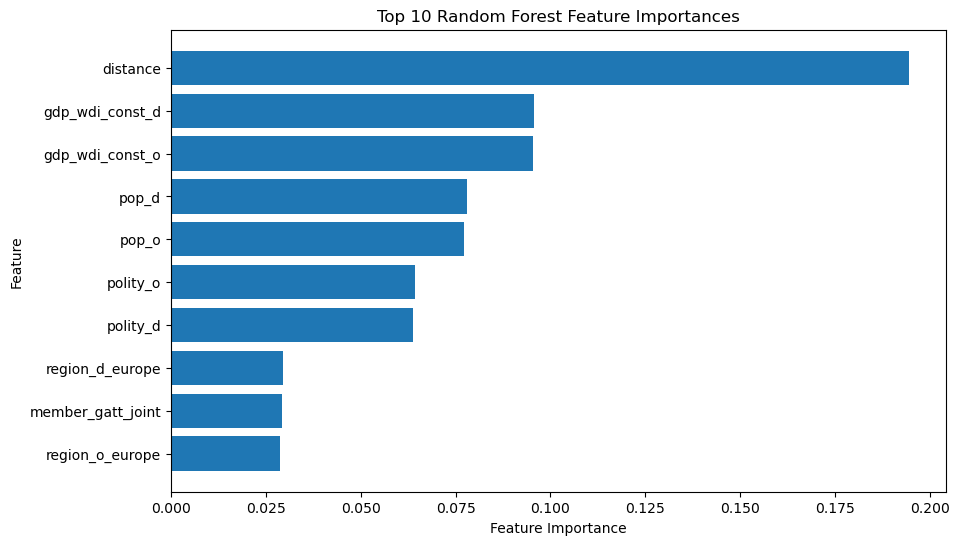

In [10]:
# Fits the random forest pipeline on the final training set
Trade_DB_rf_pipeline.fit(Trade_DB_X_train_final, Trade_DB_y_train_final)

# Gets the preprocessing step from the random forest pipeline
Trade_DB_rf_preprocess = Trade_DB_rf_pipeline.named_steps["preprocess"]

# Gets the random forest model from the pipeline
Trade_DB_rf_model = Trade_DB_rf_pipeline.named_steps["model"]

# Gets feature names after preprocessing
Trade_DB_rf_feature_names = Trade_DB_rf_preprocess.get_feature_names_out()

# Removes num__ and cat__ from the feature names
Trade_DB_rf_feature_names_clean = [
    feature.replace("num__", "").replace("cat__", "")
    for feature in Trade_DB_rf_feature_names
]

# Gets feature importance scores from the random forest model
Trade_DB_rf_importance_scores = Trade_DB_rf_model.feature_importances_

# Creates dataframe of feature names and importance scores
Trade_DB_rf_importance_df = pd.DataFrame({
    "feature": Trade_DB_rf_feature_names_clean,
    "importance": Trade_DB_rf_importance_scores
})

# Sorts the feature importance scores from highest to lowest
Trade_DB_rf_importance_df = Trade_DB_rf_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Keeps only the top 10 most important features
Trade_DB_rf_top10 = Trade_DB_rf_importance_df.head(10)

# Prints the top 10 most important features
print(Trade_DB_rf_top10)

# Creates top 10 feature importance graph
plt.figure(figsize=(10, 6))
plt.barh(Trade_DB_rf_top10["feature"], Trade_DB_rf_top10["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

## <a id='toc1_11_'></a>[Multi-Metric Comparison of Validation Models](#toc0_)

- The multi-metric validation graph compares the average cross validation results for logistic regression, random forest, and KNN across precision, recall, F1 score, and ROC-AUC. 
- Logistic regression performed the weakest across all four metrics. This suggests that a linear model is not able to capture the complex nature of how the predictor variables interact. 
- Random forest and KNN both performed better than logistic regression on every metric. This suggests that nonlinear and similarity-based models fit this problem better. 
- KNN had the highest precision in cross validation. This means it was the most accurate when predicting that a country pair had a trade agreement. 
- Random forest had the highest recall in cross validation. This means it identified the largest share of country pairs that actually had trade agreements. 
- Random forest and KNN had very similar F1 scores, but random forest was slightly higher. This suggests that random forest had the strongest overall balance between precision and recall during cross validation. 
- Random forest had the highest ROC-AUC. This means it separated the two classes slightly better than KNN, but both were much better than logistic regression. 
- The validation graph suggests that random forest was the strongest model during cross validation, while KNN was a strong second. 
- A limitation is that the very strong random forest and KNN results may reflect repeated country-pair patterns across years. This makes prediction easier.

Average cross validation results:
           Logistic Regression  Random Forest  K Nearest Neighbors
precision             0.279955       0.918389             0.973016
recall                0.667855       0.943864             0.873384
f1                    0.394362       0.930704             0.920192
roc_auc               0.781233       0.991674             0.982355



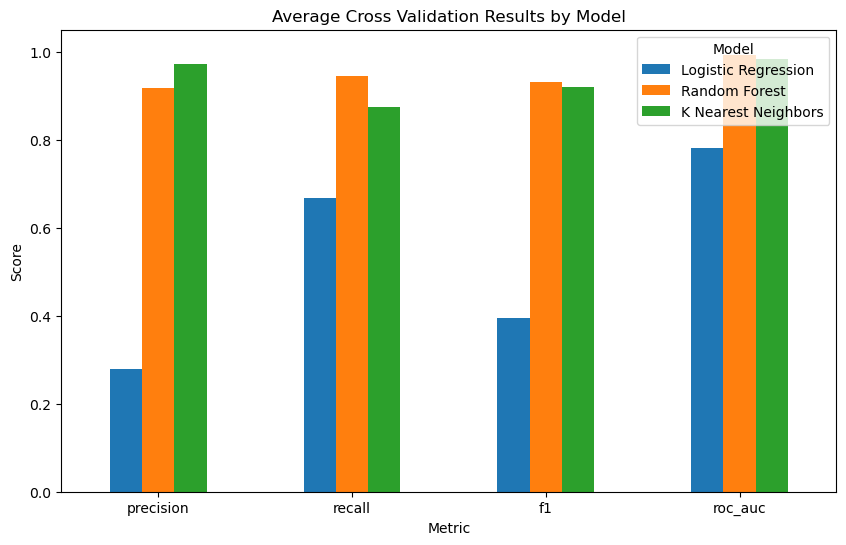

In [11]:
# Creates average cross validation results for logistic regression
Trade_DB_logit_cv_avg = Trade_DB_cv_summary_logit[["precision", "recall", "f1", "roc_auc"]].mean()

# Creates average cross validation results for random forest
Trade_DB_rf_cv_avg = Trade_DB_cv_summary_rf[["precision", "recall", "f1", "roc_auc"]].mean()

# Creates average cross validation results for K nearest neighbors
Trade_DB_knn_cv_avg = Trade_DB_cv_summary_knn[["precision", "recall", "f1", "roc_auc"]].mean()

# Combines the average cross validation results into one dataframe
Trade_DB_cv_compare = pd.DataFrame({
    "Logistic Regression": Trade_DB_logit_cv_avg,
    "Random Forest": Trade_DB_rf_cv_avg,
    "K Nearest Neighbors": Trade_DB_knn_cv_avg
})

# Prints the comparison table
print("Average cross validation results:")
print(Trade_DB_cv_compare)
print()

# Creates grouped bar chart for average cross validation results
Trade_DB_cv_compare.plot(kind="bar", figsize=(10, 6))

# Adds chart labels and title
plt.title("Average Cross Validation Results by Model")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.ylim(0, 1.05)
plt.show()

## <a id='toc1_12_'></a>[Multi-Metric Comparison of Final Test Models](#toc0_)

- The final test multi-metric graph compares logistic regression, random forest, and KNN on the held out 2015 to 2016 test set using precision, recall, F1 score, and ROC-AUC. 
- The final test set was left out of model development and cross validation, so it provides a more realistic measure of how the models perform on unseen future data. 
- Logistic regression had the weakest overall performance on the final test set. It had low precision but higher recall. This means it identified many true trade agreement cases but made many false positive predictions. 
- Random forest had the highest precision and the highest ROC-AUC on the final test set. This means it was usually correct when it predicted a trade agreement and it separated the two classes very well. 
- Random forest had much lower recall than expected from cross validation. This means it missed many true trade agreement cases on the final test set. 
- KNN had strong precision, recall, F1 score, and ROC-AUC on the final test set. 
- KNN had the highest F1 score. This means it had the best overall balance between precision and recall on the final test set. 
- Compared to random forest, KNN had lower precision and slightly lower ROC-AUC. KNN had much higher recall and a better F1 score. 
- Compared to logistic regression, KNN had much higher precision, higher F1 score, higher ROC-AUC, and a similar recall. 
- The final test results suggest that KNN was the strongest model if the goal is to balance false positives and false negatives. 
- Random forest may still be preferred if the goal is to minimize false positive predictions, because it had the highest precision. 
- The final test results for random forest and KNN are weaker than their cross validation results. This suggests that the very strong cross validation performance may have been partly helped by repeated country pair patterns across years.

Final test results:
                     precision    recall        f1   roc_auc
model                                                       
Logistic Regression   0.308537  0.636325  0.415574  0.779271
Random Forest         0.905940  0.414690  0.568947  0.905666
K Nearest Neighbors   0.848111  0.628472  0.721956  0.884983



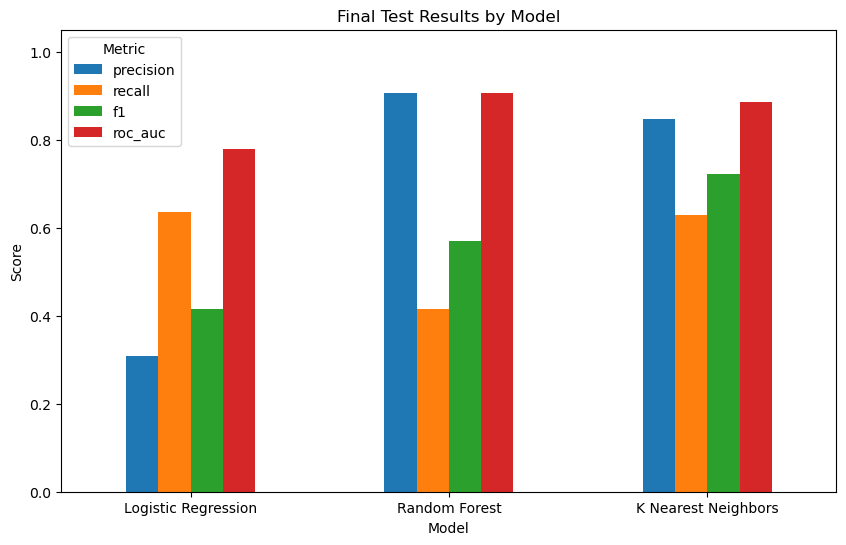

In [12]:
# Creates dataframe of final test results with model names as the index
Trade_DB_final_compare = Trade_DB_final_results.set_index("model")[["precision", "recall", "f1", "roc_auc"]]

# Prints the final test comparison table
print("Final test results:")
print(Trade_DB_final_compare)
print()

# Creates grouped bar chart for final test results
Trade_DB_final_compare.plot(kind="bar", figsize=(10, 6))

# Adds chart labels and title
plt.title("Final Test Results by Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.ylim(0, 1.05)
plt.show()

## <a id='toc1_13_'></a>[Limitations](#toc0_)

- The dataset covers 2005–2016, which is a period before major global trade disruptions such as Brexit, the US–China trade war, and the COVID-19 pandemic. 
- Because of this, conclusions drawn from this dataset may not fully apply to the current global trade environment. 
- The data used in this project is the most recent version published by the US International Trade Commission, but the full dataset goes back much farther in time. A shorter time period was used to reduce model processing time. 
- Using only 2005–2016 may limit the amount of historical variation captured in the models. 
- Random forest imputation was used to estimate missing numeric values. These imputed values are not observed data and may carry forward patterns or biases already present in the dataset. 
- Many variables were dropped during cleaning because of leakage, redundancy, or high missingness. This may have removed some useful information from the models. 
- The dataset is significantly imbalanced, with 86.66% of observations being negative cases and 13.34% being positive cases. 
- Because of this imbalance, the models can appear strong overall while still performing unevenly when identifying actual trade agreements. 
- Random forest and KNN had very strong validation results. These results may be partly explained by repeated country-pair patterns across years, which can make prediction easier. 
- The same country pairs appear in multiple years, so the models may be learning persistent pair-level patterns rather than fully general trade agreement patterns. 
- The final test set should be trusted more than the validation folds because it uses later unseen years, but it still contains country pairs that may have appeared in earlier years. 
- This means the final test set is a stronger evaluation than cross validation alone, but it is not the same as testing on completely new country pairs. 
- Some models on this dataset take a long time to run, and long processing times limited how many model choices and tuning options could be explored. 
- The results in this project are predictive. The models can show which variables are useful for prediction, but they do not prove that those variables cause trade agreements.
- Impurity-based feature importance can favor continuous variables or variables with many possible split points.
- The dataset contains directional country-pair observations. These observations were kept because some gravity dataset variables are directional, but this may make the dataset partly redundant.

## <a id='toc1_14_'></a>[Ethics](#toc0_)

- The Dynamic Gravity Dataset reflects historical trade relationships shaped by geopolitical power, colonialism, and economic inequality. 
- Because of this, models trained on the data may learn and reproduce those historical patterns. 
- The models may systematically underestimate the likelihood of trade agreements among lower-income countries or countries that have been historically marginalized in the global economy. 
- The dataset is imbalanced, with many more cases of no trade agreement than trade agreement. 
- This class imbalance can bias results toward the majority class and make some models appear stronger than they really are. 
- Coding steps were taken to reduce the effects of class imbalance on model performance. 
- To evaluate the models more fairly, metrics such as precision, recall, F1 score, and ROC-AUC were used instead of raw accuracy alone. 
- Missing numeric values were imputed in some models, which means some inputs were estimated rather than directly observed. 
- Imputation can introduce additional bias if the missing data is not random or if the imputed values reflect patterns already embedded in the dataset. 
- The results of this project are predictive. This means the models can identify patterns associated with trade agreements, but they cannot prove that these variables cause trade agreements to occur. 
- A model that predicts trade agreement formation could potentially be used by governments, firms, or other actors to identify and exploit weaknesses in trade policy. 
- If used in real decision making, this model could advantage already powerful countries, firms, or institutions while further disadvantaging weaker or less represented countries. 
- Strong model performance can create false confidence if users assume the predictions are objective or neutral. 
- This is important because the dataset may not capture all of the political, diplomatic, and historical factors that shape real trade agreement decisions. 

## <a id='toc1_15_'></a>[Reflection](#toc0_)

- This project showed that predicting trade agreements is more complicated than just choosing the model with the highest score.
- One of the biggest things we learned was that preprocessing decisions matter a lot. Removing leakage variables, self-pairs, redundant variables, and high-missing variables was necessary before modeling.
- We learned that class imbalance can make model results misleading if the wrong metrics are used. Precision, recall, F1 score, and ROC-AUC were more useful than accuracy for evaluating the models.
- Logistic regression worked as a useful baseline, but it showed that a simple linear model could not capture the structure of the dataset very well.
- Random forest and KNN performed much better, which suggests that the relationships in this dataset are more complex and nonlinear.
- After the validation results, random forest and KNN looked extremely strong.
- However, the final test results showed that those validation results were probably helped by repeated country-pair patterns across years.
- This was one of the most important lessons from the project because it showed that strong validation results do not always mean the model will perform the same way on unseen future data.
- The final test set was more useful than the validation folds for judging which model performed best overall.
- The final test results showed KNN had the best balance between precision and recall, while random forest had the highest precision.
- We learned that prediction and explanation are not the same thing.
- The models could predict trade agreement outcomes, but additional steps like feature importance were needed to better answer what variables actually mattered most.
- The feature importance results suggest that distance, GDP, population, and shared institutions are the strongest predictors of trade agreements.
- One improvement would be to test the models on completely new country pairs instead of only later years.
- Another improvement would be to tune the models more carefully and compare more settings for random forest and KNN. This wasn't done because of absurdly long model run times.
- The last improvement would be using more datapoints. The Dynamic Gravity Dataset starts at 1945. This would cause a lot more data preprocessing steps and create longer run times. 
- This project showed that trade agreements can be predicted to some extent using geographic, economic, political, and institutional variables. It also showed the importance of careful preprocessing, realistic evaluation, and cautious interpretation.

## <a id='toc1_16_'></a>[References](#toc0_)

- https://catalog.data.gov/dataset/dynamic-gravity-dataset-1948-2016 
- https://www.usitc.gov/data/gravity/dgd.htm 
- https://www.usitc.gov/publications/332/working_papers/gurevich_herman_2018_dynamic_gravity_dataset_201802a.pdf 
- https://www.usitc.gov/data/gravity/dgd_docs/gravity_dataset_documentation_version_2_00.pdf 
- https://www.usitc.gov/press_room/about_usitc.htm 

## <a id='toc1_17_'></a>[AI Transparency](#toc0_)

ChatGPT 5.2 Thinking was used to problem solve Random Forest Imputation for numeric variables and implementing KNN. It was also used to understand and implement time based validation folds. Drafts were used to check against the grading rubric to ensure all grading criteria were hit. Lastly, it was used as a refinement tool for spelling, grammar, and punctuation. The structure, writing, and coding decisions for this project reflect my own work.